# Hồi quy tuyến tính đa biến (Multiple Linear Regression) 🏠
Thực hành xây dựng mô hình OLS cơ bản, đánh giá mô hình với $R^2$, kiểm tra phương sai phần dư và kiểm định giả thuyết thống kê.


Import thư viện

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Giải thích vai trò của các thư viện  
pandas: Xử lý dữ liệu  
numpy: Tính toán ma trận  
matplotlib: Vẽ biểu đồ  
scipy: Tính toán

# Phần 1 — Xây dựng mô hình OLS cơ bản

### Bước 1 — Làm quen với dữ liệu


In [117]:
# Tạo DataFrame bằng pandas.
df = pd.read_csv("house_price.csv")
df

,Area,Bedrooms,Age,Price
0,50,2,5,2500
1,55,2,10,2600
2,60,3,5,3100
3,65,3,10,3200
4,70,3,15,3250
5,75,4,5,3800
6,80,4,10,3900
7,85,4,20,3850
8,90,5,10,4500
9,100,5,5,4800


In [118]:
# Xem số dòng, số cột
df.shape


(10, 4)

In [119]:
# Xem kiểu dữ liệu
df.dtypes

Area        int64
Bedrooms    int64
Age         int64
Price       int64
dtype: object

In [120]:
# Kiểm tra missing values
df.isnull().sum()

Area        0
Bedrooms    0
Age         0
Price       0
dtype: int64

### Bước 2 — Tách X và Y


In [121]:
# Phần 2 - Tách X và Y
X = df[['Area', 'Bedrooms', 'Age']]
Y = df[['Price']]

print(X)
print(Y)
print(X.shape)
print(Y.shape)


   Area  Bedrooms  Age
0    50         2    5
1    55         2   10
2    60         3    5
3    65         3   10
4    70         3   15
5    75         4    5
6    80         4   10
7    85         4   20
8    90         5   10
9   100         5    5
   Price
0   2500
1   2600
2   3100
3   3200
4   3250
5   3800
6   3900
7   3850
8   4500
9   4800
(10, 3)
(10, 1)


### Bước 3 — Thêm hệ số chặn (Intercept)


In [122]:
# Phần 3 - Thêm intercept
X = df[['Area', 'Bedrooms', 'Age']].copy()
X.insert(0, 'Intercept', 1)
print(X)
print(X.shape)


   Intercept  Area  Bedrooms  Age
0          1    50         2    5
1          1    55         2   10
2          1    60         3    5
3          1    65         3   10
4          1    70         3   15
5          1    75         4    5
6          1    80         4   10
7          1    85         4   20
8          1    90         5   10
9          1   100         5    5
(10, 4)


### Bước 4 — Tính hệ số OLS bằng NumPy


In [123]:
# Phần 4 - Tính hệ số OLS bằng NumPy
# Chuyển thành array numpy để tính toán ma trận
X_mat = X.to_numpy()
Y_mat = Y.to_numpy()

# Tính Xᵀ
XT = X_mat.T
print('Ma trận XT:\n', XT)

# Tính XᵀX
XT_X = XT @ X_mat
print('Ma trận XT_X:\n', XT_X)

# Tính (XᵀX)⁻¹
XT_X_inv = np.linalg.inv(XT_X)
print('Ma trận (XT_X)^(-1):\n', XT_X_inv)

# Tính XᵀY
XT_Y = XT @ Y_mat
print('Vector XT_Y:\n', XT_Y)

# Tính β = (XᵀX)⁻¹XᵀY
beta = XT_X_inv @ XT_Y
print('Hệ số beta OLS:\n', beta)


Ma trận XT:
 [[  1   1   1   1   1   1   1   1   1   1]
 [ 50  55  60  65  70  75  80  85  90 100]
 [  2   2   3   3   3   4   4   4   5   5]
 [  5  10   5  10  15   5  10  20  10   5]]
Ma trận XT_X:
 [[   10   730    35    95]
 [  730 55600  2705  7075]
 [   35  2705   133   335]
 [   95  7075   335  1125]]
Ma trận (XT_X)^(-1):
 [[ 4.63760218e+00 -1.60217984e-01  1.94686649e+00  3.62397820e-02]
 [-1.60217984e-01  8.46503179e-03 -1.19981835e-01 -3.97820163e-03]
 [ 1.94686649e+00 -1.19981835e-01  1.79609446e+00  5.53133515e-02]
 [ 3.62397820e-02 -3.97820163e-03  5.53133515e-02  6.37602180e-03]]
Vector XT_Y:
 [[  35500]
 [2698750]
 [ 131550]
 [ 338750]]
Hệ số beta OLS:
 [[633.10626703]
 [ 26.03996367]
 [326.40781108]
 [-13.3106267 ]]


### Bước 5 — Dự đoán (Prediction)


In [124]:
# Phần 5 - Prediction
df['Predicted_Price'] = X @ beta
df


,Area,Bedrooms,Age,Price,Predicted_Price
0,50,2,5,2500,2521.366939
1,55,2,10,2600,2585.013624
2,60,3,5,3100,3108.174387
3,65,3,10,3200,3171.821072
4,70,3,15,3250,3235.467757
5,75,4,5,3800,3825.181653
6,80,4,10,3900,3888.828338
7,85,4,20,3850,3885.921889
8,90,5,10,4500,4475.635786
9,100,5,5,4800,4802.588556


### Bước 6 — Phần dư (Residual)


In [125]:
# Phần 6 - Residual
df['Residual'] = df['Price'] - df['Predicted_Price']
df

,Area,Bedrooms,Age,Price,Predicted_Price,Residual
0,50,2,5,2500,2521.366939,-21.366939
1,55,2,10,2600,2585.013624,14.986376
2,60,3,5,3100,3108.174387,-8.174387
3,65,3,10,3200,3171.821072,28.178928
4,70,3,15,3250,3235.467757,14.532243
5,75,4,5,3800,3825.181653,-25.181653
6,80,4,10,3900,3888.828338,11.171662
7,85,4,20,3850,3885.921889,-35.921889
8,90,5,10,4500,4475.635786,24.364214
9,100,5,5,4800,4802.588556,-2.588556


In [126]:
# Kiểm tra tổng Residual
df['Residual'].sum()

np.float64(9.276845958083868e-10)

### Bước 7 — Tổng bình phương sai số (SSE / RSS)


In [127]:
# Phần 7 - SSE / RSS
df['SSE'] = df['Residual'] ** 2
df

,Area,Bedrooms,Age,Price,Predicted_Price,Residual,SSE
0,50,2,5,2500,2521.366939,-21.366939,456.546088
1,55,2,10,2600,2585.013624,14.986376,224.591466
2,60,3,5,3100,3108.174387,-8.174387,66.820602
3,65,3,10,3200,3171.821072,28.178928,794.051997
4,70,3,15,3250,3235.467757,14.532243,211.186099
5,75,4,5,3800,3825.181653,-25.181653,634.115650
6,80,4,10,3900,3888.828338,11.171662,124.806035
7,85,4,20,3850,3885.921889,-35.921889,1290.382123
8,90,5,10,4500,4475.635786,24.364214,593.614941
9,100,5,5,4800,4802.588556,-2.588556,6.700621


In [128]:
# Tổng SSE
SSE = df['SSE'].sum()
SSE

np.float64(4402.815622161672)

### Bước 8 — Thử dự đoán một căn nhà mới


In [129]:
# Phần 8 - Thử dự đoán một căn nhà mới
X_new = np.array([1, 80, 3, 8])
print(X_new)

# Tính Ŷ_new = X_newβ
Y_new = X_new @ beta
print(Y_new)


[ 1 80  3  8]
[3589.0417802]


### Bước 9 — Câu hỏi củng cố hiểu bài / Diễn giải phương trình


In [130]:
beta

array([[633.10626703],
       [ 26.03996367],
       [326.40781108],
       [-13.3106267 ]])

B0: Ảnh hưởng của tất cả các biến khác tới giá nhà  

B1: Trong điều kiện biến khác không đổi, diện tích tăng 1m2 thì giá nhà tăng 26.03996367 triệu đồng.  

B2: Trong điều kiện biến khác không đổi, số phòng ngủ tăng 1 phòng thì giá nhà tăng 326.40781108 triệu đồng.  

B3: Trong điều kiện biến khác không đổi, tuổi nhà tăng 1 năm thì giá nhà giảm 13.3106267 triệu đồng.

# Phần 2 — Đánh giá mô hình với $R^2$ và Adjusted $R^2$ 📊

### Bước 10 — Tính $R^2$ (Hệ số xác định)


In [131]:
# Tính Y trung bình
Y_mean = Y_mat.mean()
Y_mean

np.float64(3550.0)

In [132]:
# Tính tổng bình phương sai lệch toàn phần TSS
TSS = ((Y_mat - Y_mean) ** 2).sum()
TSS

np.float64(5160000.0)

In [133]:
# Tính R2
R2 = 1 - (SSE/TSS)
R2


np.float64(0.9991467411584958)

### Bước 11 — Giải thích ý nghĩa của $R^2$


Mô hình giải thích 99.91% sự biến thiên của giá nhà

### Bước 12 — Tính Adjusted $R^2$


In [134]:
# Bước 3 - Tính Adjusted R2
n = df.shape[0]
k = X.shape[1] - 1
print(n)
print(k)


10
3


In [135]:
Adjusted_R2 = 1 - ((1 - R2) * (n - 1) / (n - k - 1))
Adjusted_R2

np.float64(0.9987201117377437)

### Bước 13 — So sánh $R^2$ và Adjusted $R^2$


In [136]:
# Bước 4 - So sánh R2 và Adjusted R2
print(R2)
print(Adjusted_R2)


0.9991467411584958
0.9987201117377437


Tại sao Adjust R2 thường nhỏ hơn R2:  
--> Trong công thức của Adjust R2 có k, k tăng thì Adjust R2 càng nhỏ

# Phần 3 — Phương sai sai số & Kiểm tra phương sai thay đổi (Heteroskedasticity) 📈

### Bước 15 — Tính phương sai sai số ($\sigma^2$) và sai số chuẩn ($\sigma$)


In [137]:
# Tính bậc tự do phần dư
df_resid = n - k - 1
df_resid

6

In [138]:
# Tính phương sai sai số (sigma^2)
sigma2 = SSE / df_resid
sigma2

np.float64(733.802603693612)

In [139]:
# Tính độ lệch chuẩn sai số (sigma)
sigma = np.sqrt(sigma2)
sigma


np.float64(27.088791108013883)

### Bước 16 — Nhận xét về quy mô sai số (Magnitude of Error)


1. Quy mô sai số tuyệt đối:  
   - Độ lệch chuẩn sai số sigma ≈ 27.09 triệu đồng.
   - Cho biết: mức chênh lệch trung bình (điển hình) giữa giá nhà thực tế và giá nhà dự đoán
     rơi vào khoảng 27 triệu đồng mỗi căn.

2. So sánh tương quan với giá nhà:
   - Giá nhà dao động từ 2,500 đến 4,800 triệu đồng (giá trung bình là 3,550 triệu đồng).
   - Tỷ lệ sai số: 27.09 / 3,550 ≈ 0.76% (chưa tới 1% giá trị căn nhà).

--> Kết luận: Quy mô sai số khoảng 27 triệu VNĐ là rất nhỏ, khẳng định mô hình có độ chính xác rất cao.

### Bước 17 — So sánh độ phân tán phần dư theo nhóm giá trị dự đoán


In [140]:
# Thêm cột Giá trị tuyệt đối của Residual
df["Residual_abs"] = df["Residual"].abs()
df

,Area,Bedrooms,Age,Price,Predicted_Price,Residual,SSE,Residual_abs
0,50,2,5,2500,2521.366939,-21.366939,456.546088,21.366939
1,55,2,10,2600,2585.013624,14.986376,224.591466,14.986376
2,60,3,5,3100,3108.174387,-8.174387,66.820602,8.174387
3,65,3,10,3200,3171.821072,28.178928,794.051997,28.178928
4,70,3,15,3250,3235.467757,14.532243,211.186099,14.532243
5,75,4,5,3800,3825.181653,-25.181653,634.115650,25.181653
6,80,4,10,3900,3888.828338,11.171662,124.806035,11.171662
7,85,4,20,3850,3885.921889,-35.921889,1290.382123,35.921889
8,90,5,10,4500,4475.635786,24.364214,593.614941,24.364214
9,100,5,5,4800,4802.588556,-2.588556,6.700621,2.588556


Tạo 2 nhóm với giá dự đoán thấp và cao

In [141]:
# 5 nhà có giá dự đoán thấp nhất
price_low = df.sort_values(by='Predicted_Price').iloc[0:5, :]
price_low

,Area,Bedrooms,Age,Price,Predicted_Price,Residual,SSE,Residual_abs
0,50,2,5,2500,2521.366939,-21.366939,456.546088,21.366939
1,55,2,10,2600,2585.013624,14.986376,224.591466,14.986376
2,60,3,5,3100,3108.174387,-8.174387,66.820602,8.174387
3,65,3,10,3200,3171.821072,28.178928,794.051997,28.178928
4,70,3,15,3250,3235.467757,14.532243,211.186099,14.532243


In [142]:
# 5 nhà có giá dự đoán cao nhất
price_high = df.sort_values(by='Predicted_Price').iloc[5:10, :]
price_high

,Area,Bedrooms,Age,Price,Predicted_Price,Residual,SSE,Residual_abs
5,75,4,5,3800,3825.181653,-25.181653,634.115650,25.181653
7,85,4,20,3850,3885.921889,-35.921889,1290.382123,35.921889
6,80,4,10,3900,3888.828338,11.171662,124.806035,11.171662
8,90,5,10,4500,4475.635786,24.364214,593.614941,24.364214
9,100,5,5,4800,4802.588556,-2.588556,6.700621,2.588556


In [143]:
# So sánh độ phân tán phần dư theo nhóm giá trị dự đoán
print("Độ phân tán phần dư của nhóm giá dự đoán thấp:", price_low['Residual_abs'].mean())
print("Độ phân tán phần dư của nhóm giá dự đoán cao:", price_high['Residual_abs'].mean())

Độ phân tán phần dư của nhóm giá dự đoán thấp: 17.44777475025112
Độ phân tán phần dư của nhóm giá dự đoán cao: 19.845594913697276


Nhận xét Bước 3:   
Mức sai số trung bình giữa 2 nhóm chênh lệch rất ít (17.45 vs 19.85), 
cho thấy phương sai sai số giữa hai nhóm tương đối đồng đều (Homoskedasticity).

### Bước 18 — Kiểm tra giả định bằng biểu đồ phần dư (Residual Plot)


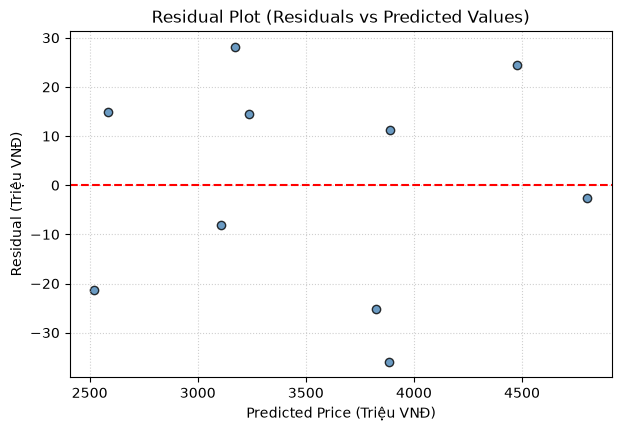

In [144]:
# Bước 18 - Vẽ biểu đồ Residual Plot
plt.figure(figsize=(7, 4.5))
plt.scatter(df['Predicted_Price'], df['Residual'], color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel("Predicted Price (Triệu VNĐ)")
plt.ylabel("Residual (Triệu VNĐ)")
plt.title("Residual Plot (Residuals vs Predicted Values)")
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


Từ biểu đồ residual plot, ta quan sát được:
- Các điểm phần dư phân tán ngẫu nhiên quanh đường y=0
- Không có dấu hiệu rõ ràng của heteroskedasticity
- Độ phân tán phần dư có xu hướng không đổi khi Predicted_Price thay đổi

### Bước 19 — Kiểm định hệ số tự do: Intercept ($\beta_0$)


In [145]:
# Lấy giá trị ước lượng beta0
beta0 = beta[0][0]
print("beta0:", beta0)

# Tính SE của beta0
SE_beta0 = np.sqrt(sigma2 * XT_X_inv[0][0])
print("SE của beta0:", SE_beta0)

# Tính t-statistic của beta0
t_beta0 = beta0 / SE_beta0
print("t-stat của beta0:", t_beta0)

# Tính p-value của beta0
p_beta0 = 2 * (1 - stats.t.cdf(abs(t_beta0), df_resid))
print("p-value của beta0:", p_beta0)


beta0: 633.106267029827
SE của beta0: 58.335962788482426
t-stat của beta0: 10.852761088822287
p-value của beta0: 3.6256296714665126e-05


Kiểm định giả thuyết  
p-value nhỏ hơn 0.05 nên bác bỏ H0  
--> Beta0 có tác động có ý nghĩa thống kê đến giá nhà

Diễn giải kết quả bằng ngôn ngữ đời thường  
Hệ số chặn (beta0) ước lượng khoảng 633.11 triệu đồng. Về mặt kỹ thuật, giá trị này đại diện cho giá trị trung bình của biến phụ thuộc (Giá nhà) khi tất cả các biến độc lập (Diện tích, Số phòng ngủ, Tuổi nhà) đều bằng 0. 
Trong bối cảnh bài toán này, việc tất cả các biến độc lập đều bằng 0 là không thực tế (ví dụ: một ngôi nhà có diện tích 0m² không tồn tại). Do đó, ý nghĩa thực tế của beta0 thường hạn chế. Tuy nhiên, nó đóng vai trò là điểm neo cho đường hồi quy và là một phần quan trọng của mô hình toán học để đảm bảo dự đoán chính xác trên tập dữ liệu. Nếu có một nhóm nhà tham chiếu trong tập dữ liệu có các đặc điểm gần với điểm gốc, beta0 có thể mang ý nghĩa thực tế hơn.

### Bước 20 — Kiểm định hệ số diện tích: $\text{Area}$ ($\beta_1$)


In [146]:
# Lấy giá trị ước lượng beta1
beta1 = beta[1][0]
print("beta1:", beta1)

# Tính Standard Error của beta1
SE_beta1 = np.sqrt(sigma2 * XT_X_inv[1][1])
print("SE của beta1:", SE_beta1)

# Tính t-statistic của beta1
t_beta1 = beta1 / SE_beta1
print("t-stat của beta1:", t_beta1)

# Tính p-value của beta1
p_beta1 = 2 * (1 - stats.t.cdf(abs(t_beta1), df_resid))
print("p-value của beta1:", p_beta1)


beta1: 26.039963669391
SE của beta1: 2.4923206790709482
t-stat của beta1: 10.448079128845412
p-value của beta1: 4.50863698631121e-05


Kiểm định giả thuyết  
p-value 4.5e-05 nhỏ hơn 0.05 nên bác bỏ H0  
--> Diện tích có tác động có ý nghĩa thống kê đến giá nhà


Diễn giải kết quả bằng ngôn ngữ đời thường  

Kết luận: Vì p-value = 4.5e-05 < 0.05, ta bác bỏ giả thuyết H0 và kết luận có bằng chứng thống kê mạnh cho thấy diện tích có ảnh hưởng có ý nghĩa thống kê đến giá nhà. Cụ thể, trong điều kiện các yếu tố khác không đổi, với mỗi 1m2 tăng thêm, giá nhà trung bình tăng khoảng 26 triệu đồng, và sự gia tăng này không phải do ngẫu nhiên.



### Bước 21 — Kiểm định hệ số số phòng ngủ: $\text{Bedrooms}$ ($\beta_2$)


In [147]:
# Kiểm định hệ số số phòng ngủ
# Lấy giá trị ước lượng beta2
beta2 = beta[2][0]
print("beta2:", beta2)

# Tính Standard Error của beta2
SE_beta2 = np.sqrt(sigma2 * XT_X_inv[2][2])
print("SE của beta2:", SE_beta2)

# Tính t-statistic của beta2
t_beta2 = beta2 / SE_beta2
print("t-stat của beta2:", t_beta2)

# Tính p-value của beta2
p_beta2 = 2 * (1 - stats.t.cdf(abs(t_beta2), df_resid))
print("p-value của beta2:", p_beta2)

beta2: 326.4078110808623
SE của beta2: 36.30397761845232
t-stat của beta2: 8.990965522052276
p-value của beta2: 0.00010586913396304354


Kiểm định giả thuyết  
p-value 0.000105 nhỏ hơn 0.05 nên bác bỏ H0  
--> Số phòng ngủ có tác động có ý nghĩa thống kê đến giá nhà

Diễn giải kết quả bằng ngôn ngữ đời thường  

Kết luận: Vì p-value = 0.000105 < 0.05, ta bác bỏ giả thuyết H0 và kết luận có bằng chứng thống kê mạnh cho thấy số phòng ngủ có ảnh hưởng có ý nghĩa thống kê đến giá nhà. Cụ thể, trong điều kiện các yếu tố khác không đổi, với mỗi phòng ngủ tăng thêm, giá nhà trung bình tăng khoảng 326 triệu đồng, và sự gia tăng này không phải do ngẫu nhiên.

### Bước 22 — Kiểm định hệ số tuổi nhà: $\text{Age}$ ($\beta_3$)


In [148]:
# Kiểm định hệ số tuổi nhà
# Lấy giá trị ước lượng beta3
beta3 = beta[3][0]
print("beta3:", beta3)

# Tính Standard Error của beta3
SE_beta3 = np.sqrt(sigma2 * XT_X_inv[3][3])
print("SE của beta3:", SE_beta3)

# Tính t-statistic của beta3
t_beta3 = beta3 / SE_beta3
print("t-stat của beta3:", t_beta3)

# Tính p-value của beta3
p_beta3 = 2 * (1 - stats.t.cdf(abs(t_beta3), df_resid))
print("p-value của beta3:", p_beta3)

beta3: -13.310626702997979
SE của beta3: 2.163039850961503
t-stat của beta3: -6.153666885555165
p-value của beta3: 0.0008443319653501646


Kiểm định giả thuyết  
p-value 0.000844 nhỏ hơn 0.05 nên bác bỏ H0
--> Tuổi nhà có tác động có ý nghĩa thống kê đến giá nhà


Diễn giải kết quả bằng ngôn ngữ đời thường  
Kết luận: Vì p-value = 0.000844 < 0.05, ta có bằng chứng thống kê mạnh cho thấy tuổi nhà có tác động có ý nghĩa thống kê đến giá nhà. Cụ thể, trong điều kiện các yếu tố khác không đổi, với mỗi năm tăng thêm, giá nhà trung bình giảm khoảng 13 triệu đồng, và sự gia tăng này không phải do ngẫu nhiên.


### Bước 23 — Bảng tổng hợp kiểm định & Chuỗi tư duy logic


In [149]:
summary = pd.DataFrame({
    'He so':       ['beta0 (Intercept)', 'beta1 (Area)', 'beta2 (Bedrooms)', 'beta3 (Age)'],
    'Uoc luong':   [round(beta[0][0], 4), round(beta1, 4), round(beta2, 4), round(beta3, 4)],
    'SE':          [round(SE_beta0, 4), round(SE_beta1, 4), round(SE_beta2, 4), round(SE_beta3, 4)],
    't-stat':      [round(t_beta0, 4), round(t_beta1, 4), round(t_beta2, 4), round(t_beta3, 4)],
    'p-value':     [round(p_beta0, 6), round(p_beta1, 6), round(p_beta2, 6), round(p_beta3, 6)],
    'Ket luan':    ['Co y nghia', 'Co y nghia', 'Co y nghia', 'Co y nghia'],
})
print('\n===== BANG TONG HOP KIEM DINH HE SO HOI QUY =====')
print(summary.to_string(index=False))



===== BANG TONG HOP KIEM DINH HE SO HOI QUY =====
            He so  Uoc luong      SE  t-stat  p-value   Ket luan
beta0 (Intercept)   633.1063 58.3360 10.8528 0.000036 Co y nghia
     beta1 (Area)    26.0400  2.4923 10.4481 0.000045 Co y nghia
 beta2 (Bedrooms)   326.4078 36.3040  8.9910 0.000106 Co y nghia
      beta3 (Age)   -13.3106  2.1630 -6.1537 0.000844 Co y nghia
